# Notebook 07 — Execution & Transaction Costs
Compute turnover, apply a simple cost model, and compare gross vs net performance.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from quant.utils.project_root import set_root

PROJECT_ROOT = set_root()
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\johng\code\quant-projects\quant-projects


In [ ]:
# Load outputs from earlier notebooks
w_port = pd.read_parquet("data/derived/weights_portfolio_vol_target.parquet")
r_port = pd.read_parquet("data/derived/portfolio_returns.parquet").iloc[:, 0]
print("Weights shape:", w_port.shape)
print("Returns length:", len(r_port))

Weights shape: (5022, 15)
Returns length: 5022


## 1) Portfolio Turnover

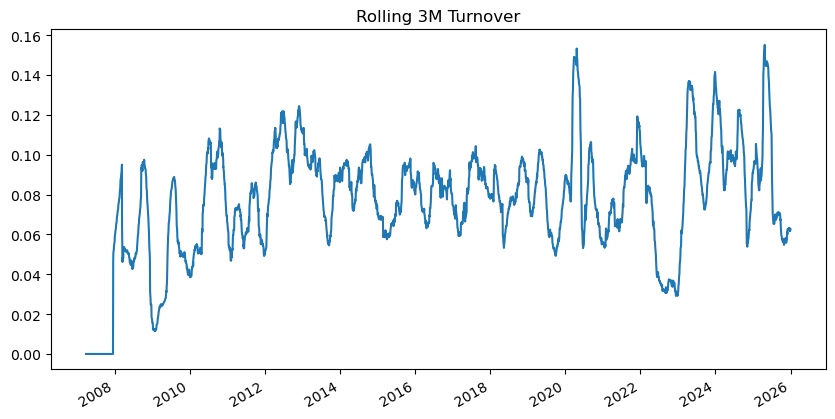

In [14]:
turnover = w_port.diff().abs().sum(axis=1)
turnover.name = "turnover"

turnover.rolling(63).mean().plot(figsize=(10, 5), title="Rolling 3M Turnover")
plt.show()

## 2) Simple transaction cost model

In [15]:
bps_cost = 5 / 10_000  # 5 bps per full round-trip
costs = bps_cost * turnover
r_net = r_port - costs
r_net.name = "r_net"

print("Mean daily cost (bps):", costs.mean() * 10_000)

Mean daily cost (bps): 0.37958603557374176


## 3) Gross vs Net performance

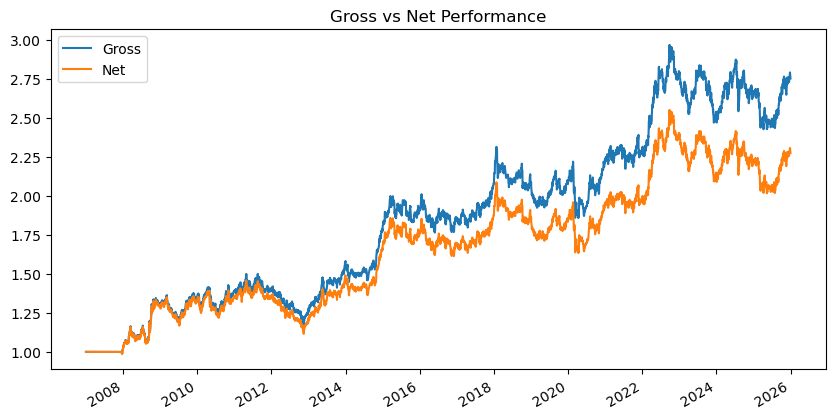

In [16]:
gross_eq = (1 + r_port).cumprod()
net_eq = (1 + r_net).cumprod()

pd.concat([gross_eq, net_eq], axis=1).plot(
    figsize=(10, 5), title="Gross vs Net Performance"
)
plt.legend(["Gross", "Net"])
plt.show()